# Análisis Exploratorio de Datos - Lotería Guácharo Activo

## Objetivo
Este notebook realiza un análisis exploratorio completo de los datos históricos de la lotería de animalitos Guácharo Activo, incluyendo:
- Análisis descriptivo de los datos
- Distribución temporal
- Análisis de frecuencias de animales
- Patrones por hora del día
- Visualizaciones con seaborn y matplotlib


In [52]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os




## 2. Carga de Datos


In [53]:
# Carga del archivo de datos
archivo = 'resultados_guacharoactivo_completo2.txt'

# Leer el archivo
df = pd.read_csv(archivo, 
                 names=['Fecha', 'Hora', 'Animal'], 
                 sep=',')

print(f"Forma del dataset: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head(10))
print(f"\nÚltimas filas:")
print(df.tail(10))


Forma del dataset: (12036, 3)

Primeras filas:
        Fecha       Hora      Animal
0  2022-12-26   09:00 AM    Pelicano
1  2022-12-26   10:00 AM         Oso
2  2022-12-26   11:00 AM      Perico
3  2022-12-26   12:00 PM       Garza
4  2022-12-26   01:00 PM     Alacran
5  2022-12-26   02:00 PM      Grillo
6  2022-12-26   03:00 PM       Tucan
7  2022-12-26   04:00 PM        Pato
8  2022-12-26   05:00 PM     Lechuza
9  2022-12-26   06:00 PM   Pavo Real

Últimas filas:
            Fecha       Hora      Animal
12026  2025-10-29   10:00 AM    Cangrejo
12027  2025-10-29   11:00 AM     Lechuza
12028  2025-10-29   12:00 PM      Perico
12029  2025-10-29   01:00 PM   Cachicamo
12030  2025-10-29   02:00 PM      Iguana
12031  2025-10-29   03:00 PM        Toro
12032  2025-10-29   04:00 PM        Mono
12033  2025-10-29   05:00 PM       Chivo
12034  2025-10-29   06:00 PM     Pescado
12035  2025-10-29   07:00 PM      Perico


## 3. Limpieza y Preparación de Datos


In [54]:
# Limpiar espacios en blanco
df['Fecha'] = df['Fecha'].str.strip()
df['Hora'] = df['Hora'].str.strip()
df['Animal'] = df['Animal'].str.strip()

# Convertir Fecha a datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

# Extraer componentes de fecha
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Dia'] = df['Fecha'].dt.day
df['DiaSemana'] = df['Fecha'].dt.day_name()
df['DiaSemanaNum'] = df['Fecha'].dt.dayofweek
df['Semana'] = df['Fecha'].dt.isocalendar().week
df['MesNombre'] = df['Fecha'].dt.month_name()

# Convertir hora a formato datetime y extraer hora numérica
df['HoraCompleta'] = pd.to_datetime(df['Hora'], format='%I:%M %p')
df['HoraNum'] = df['HoraCompleta'].dt.hour
df['Minuto'] = df['HoraCompleta'].dt.minute

# Crear columna de fecha y hora completa
df['FechaHora'] = df['Fecha'] + pd.to_timedelta(df['HoraNum'], unit='h') + pd.to_timedelta(df['Minuto'], unit='m')

print("Información del dataset:")
print(df.info())
print(f"\nValores nulos:")
print(df.isnull().sum())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12036 entries, 0 to 12035
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Fecha         12036 non-null  datetime64[ns]
 1   Hora          12036 non-null  object        
 2   Animal        12036 non-null  object        
 3   Año           12036 non-null  int32         
 4   Mes           12036 non-null  int32         
 5   Dia           12036 non-null  int32         
 6   DiaSemana     12036 non-null  object        
 7   DiaSemanaNum  12036 non-null  int32         
 8   Semana        12036 non-null  UInt32        
 9   MesNombre     12036 non-null  object        
 10  HoraCompleta  12036 non-null  datetime64[ns]
 11  HoraNum       12036 non-null  int32         
 12  Minuto        12036 non-null  int32         
 13  FechaHora     12036 non-null  datetime64[ns]
dtypes: UInt32(1), datetime64[ns](3), int32(6), object(4)
memory u

In [55]:
# Estadísticas básicas

print("ESTADÍSTICAS")

print(f"\nRango de fechas:")
print(f"Desde: {df['Fecha'].min()}")
print(f"Hasta: {df['Fecha'].max()}")
print(f"Total de días: {(df['Fecha'].max() - df['Fecha'].min()).days} días")
print(f"Total de registros: {len(df):,}")

print(f"\nNúmero único de animales: {df['Animal'].nunique()}")
print(f"\nAnimales únicos:")
# Filtrar valores nulos antes de ordenar
animales_unicos = df['Animal'].dropna().unique()
print(sorted(animales_unicos))

print(f"\nHoras disponibles: {sorted(df['HoraNum'].unique())}")
print(f"Total de horas por día: {df['HoraNum'].nunique()}")


ESTADÍSTICAS

Rango de fechas:
Desde: 2022-12-26 00:00:00
Hasta: 2025-10-29 00:00:00
Total de días: 1038 días
Total de registros: 12,036

Número único de animales: 78

Animales únicos:
['', 'Aguila', 'Alacran', 'Arana', 'Ardilla', 'Avestruz', 'Avispa', 'Ballena', 'Bisonte', 'Bufalo', 'Burro', 'Caballo', 'Cachicamo', 'Caiman', 'Camaleon', 'Camello', 'Canario', 'Cangrejo', 'Canguro', 'Caracol', 'Carnero', 'Cebra', 'Chiguire', 'Chivo', 'Ciempies', 'Cochino', 'Conejo', 'Culebra', 'Delfin', 'Elefante', 'Gallina', 'Gallo', 'Garza', 'Gato', 'Gavilan', 'Gorila', 'Grillo', 'Guacamaya', 'Guacharo', 'Hipopotamo', 'Hormiga', 'Iguana', 'Jaguar', 'Jirafa', 'Lapa', 'Lechuza', 'Leon', 'Lobo', 'Mariposa', 'Mono', 'Oso', 'Oso Hormiguero', 'Paloma', 'Panda', 'Pantera', 'Pato', 'Pavo', 'Pavo Real', 'Pelicano', 'Pereza', 'Perico', 'Perro', 'Pescado', 'Puercoespin', 'Pulpo', 'Puma', 'Rana', 'Raton', 'Tiburon', 'Tigre', 'Toro', 'Tortuga', 'Tucan', 'Turpial', 'Vaca', 'Venado', 'Zamuro', 'Zorro']

Horas dispon

## 4. Análisis Temporal


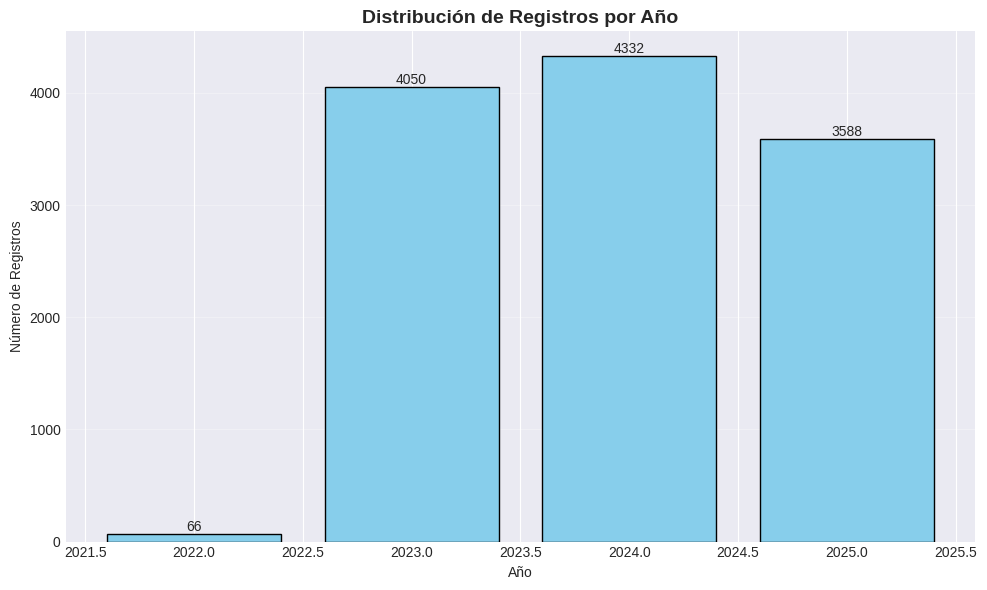

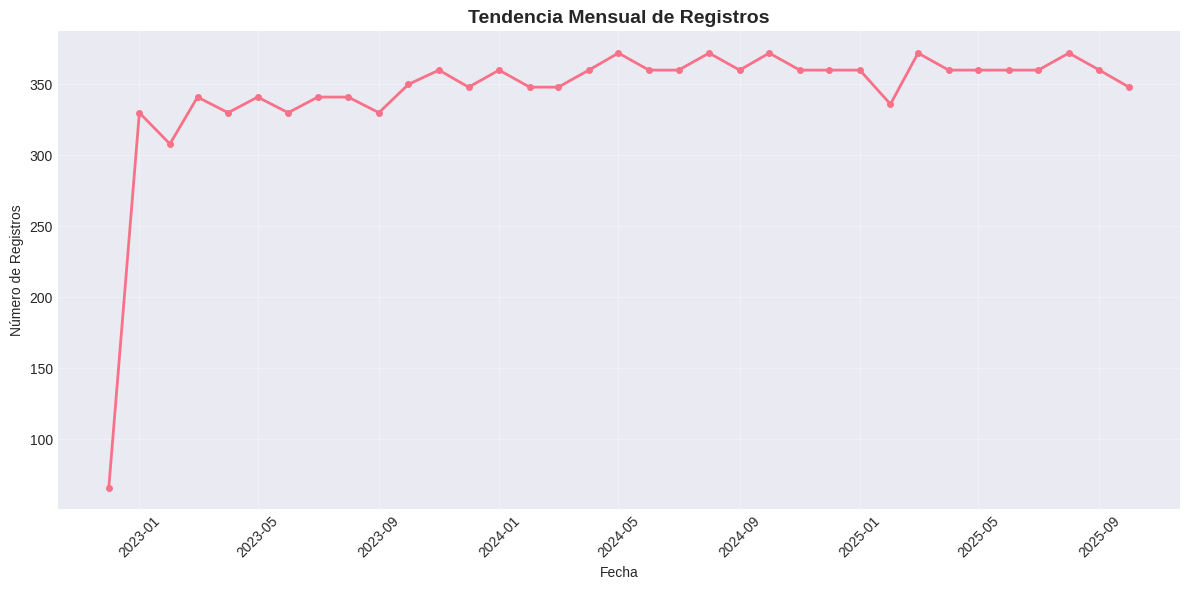

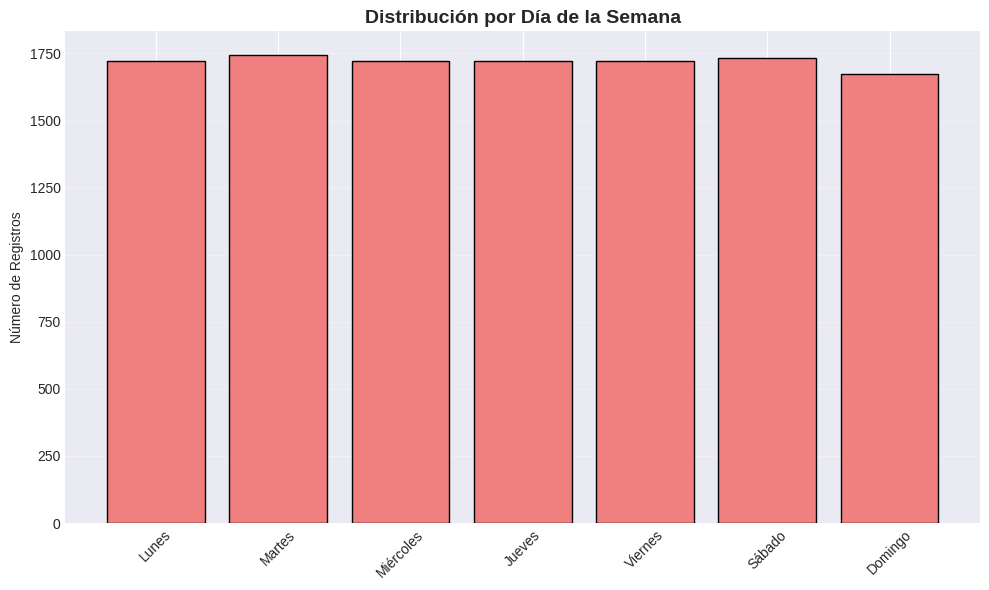

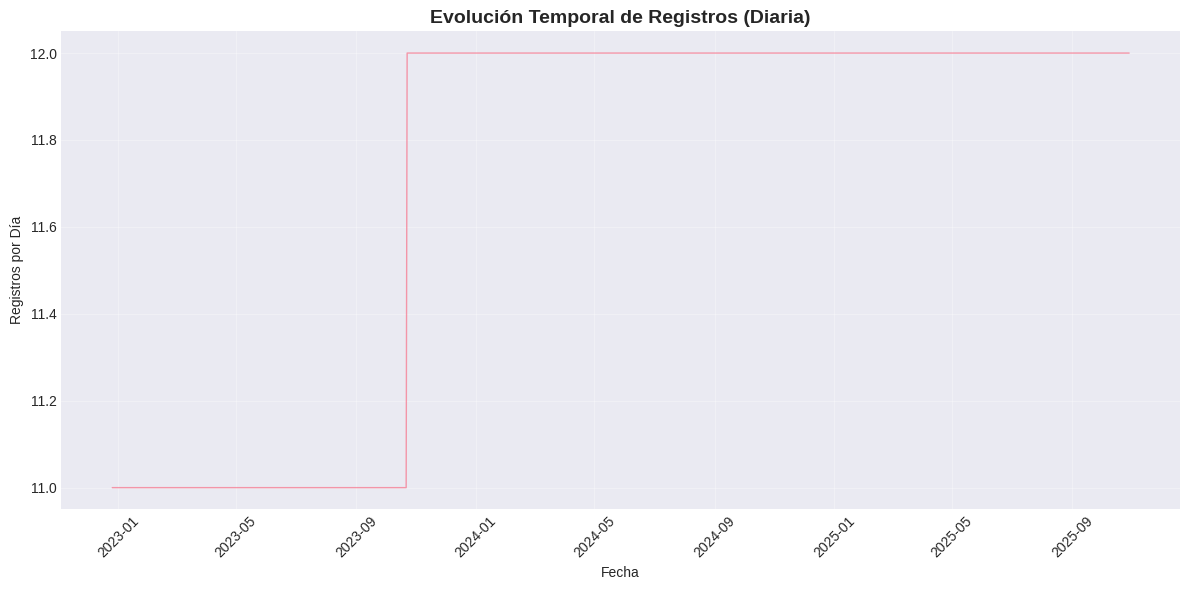


Resumen por día de la semana:
DiaSemana
Friday       1721
Monday       1721
Saturday     1733
Sunday       1674
Thursday     1721
Tuesday      1745
Wednesday    1721
Name: count, dtype: int64


In [56]:
# Distribución de registros por año - GRÁFICOS INDIVIDUALES

# 1. Registros por año
registros_por_año = df['Año'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(registros_por_año.index, registros_por_año.values, color='skyblue', edgecolor='black')
plt.title('Distribución de Registros por Año', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Número de Registros')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(registros_por_año.values):
    plt.text(registros_por_año.index[i], v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 2. Registros por mes
registros_por_mes = df.groupby(['Año', 'Mes']).size().reset_index(name='Count')
# Crear fecha desde año y mes usando un método más directo
registros_por_mes['Fecha'] = pd.to_datetime(
    registros_por_mes['Año'].astype(str) + '-' + 
    registros_por_mes['Mes'].astype(str) + '-01'
)
plt.figure(figsize=(12, 6))
plt.plot(registros_por_mes['Fecha'], registros_por_mes['Count'], marker='o', linewidth=2, markersize=4)
plt.title('Tendencia Mensual de Registros', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Registros')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Distribución por día de la semana
dias_semana = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_esp = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
registros_dia_semana = df['DiaSemana'].value_counts().reindex(dias_semana)
plt.figure(figsize=(10, 6))
plt.bar(range(len(dias_esp)), registros_dia_semana.values, color='lightcoral', edgecolor='black')
plt.xticks(range(len(dias_esp)), dias_esp, rotation=45)
plt.title('Distribución por Día de la Semana', fontsize=14, fontweight='bold')
plt.ylabel('Número de Registros')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Timeline de registros
timeline = df.groupby('Fecha').size().reset_index(name='Count')
plt.figure(figsize=(12, 6))
plt.plot(timeline['Fecha'], timeline['Count'], linewidth=1, alpha=0.7)
plt.title('Evolución Temporal de Registros (Diaria)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Registros por Día')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nResumen por día de la semana:")
print(df['DiaSemana'].value_counts().sort_index())


## 5. Análisis de Frecuencias de Animales


In [57]:
# Frecuencia de animales
frecuencia_animales = df['Animal'].value_counts()

print("TOP 10 ANIMALES MÁS FRECUENTES")

print(frecuencia_animales.head(10))

print(f"\n\nEstadísticas:")
print(f"Animal más frecuente: {frecuencia_animales.index[0]} ({frecuencia_animales.iloc[0]} apariciones)")
print(f"Animal menos frecuente: {frecuencia_animales.index[-2]} ({frecuencia_animales.iloc[-2]} apariciones)")
print(f"Diferencia: {frecuencia_animales.iloc[0] - frecuencia_animales.iloc[-2]} apariciones")




TOP 10 ANIMALES MÁS FRECUENTES
Animal
Canguro      186
Delfin       183
Pelicano     179
Lechuza      179
Tucan        178
Cachicamo    178
Camaleon     176
Venado       175
Puma         175
Jaguar       174
Name: count, dtype: int64


Estadísticas:
Animal más frecuente: Canguro (186 apariciones)
Animal menos frecuente: Guacharo (67 apariciones)
Diferencia: 119 apariciones


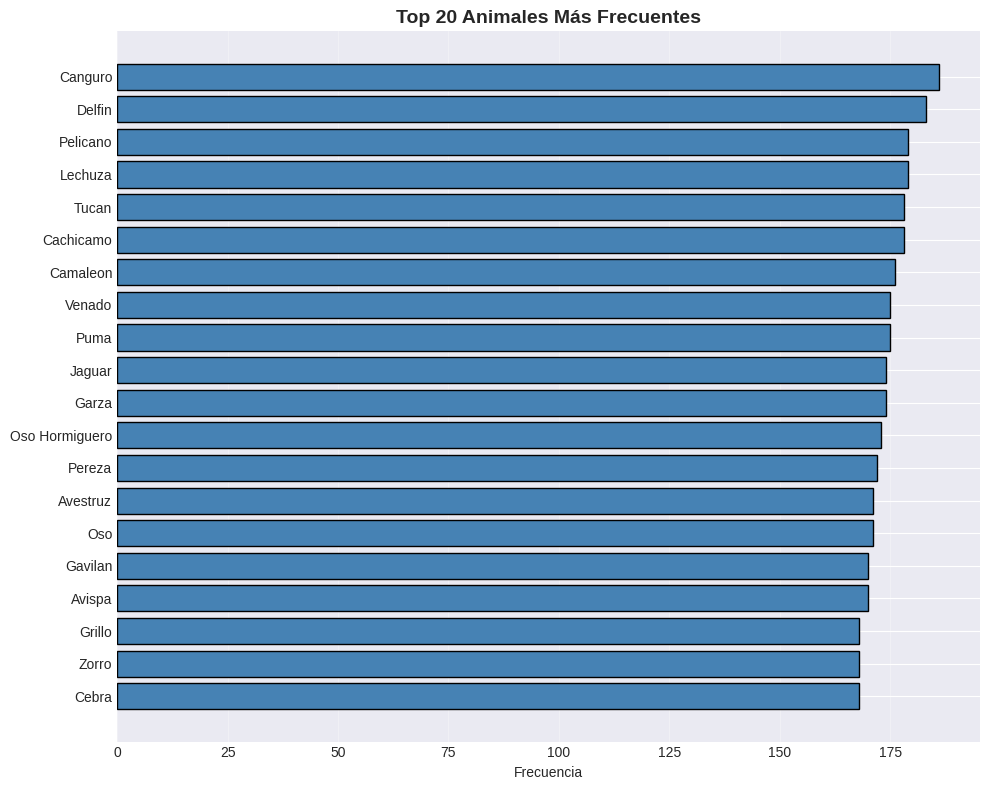

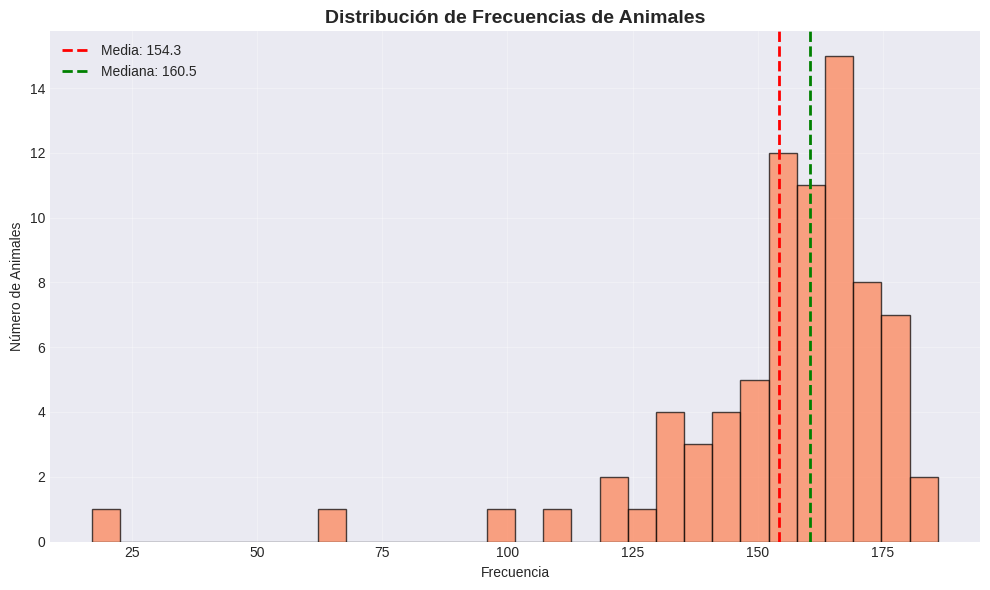

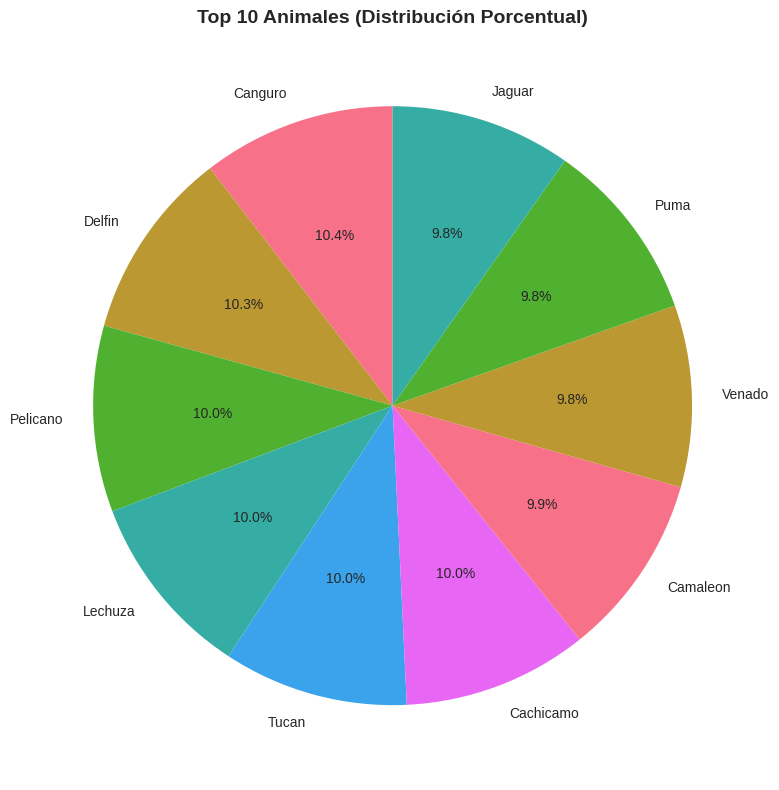

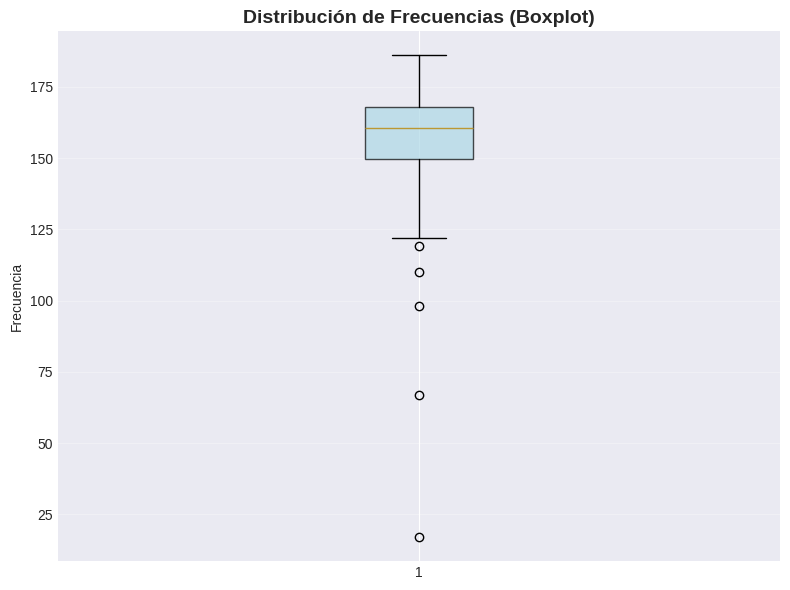

In [58]:
# Visualización de frecuencias de animales - GRÁFICOS INDIVIDUALES

# 1. Top 20 animales más frecuentes
top_20 = frecuencia_animales.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(len(top_20)), top_20.values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top_20)), top_20.index)
plt.gca().invert_yaxis()
plt.title('Top 20 Animales Más Frecuentes', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Distribución de frecuencias (histograma)
plt.figure(figsize=(10, 6))
plt.hist(frecuencia_animales.values, bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(frecuencia_animales.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {frecuencia_animales.mean():.1f}')
plt.axvline(frecuencia_animales.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {frecuencia_animales.median():.1f}')
plt.title('Distribución de Frecuencias de Animales', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia')
plt.ylabel('Número de Animales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Top 10 animales más frecuentes (gráfico circular)
top_10 = frecuencia_animales.head(10)
plt.figure(figsize=(10, 8))
plt.pie(top_10.values, labels=top_10.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 10 Animales (Distribución Porcentual)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Boxplot de frecuencias
plt.figure(figsize=(8, 6))
plt.boxplot(frecuencia_animales.values, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
plt.title('Distribución de Frecuencias (Boxplot)', fontsize=14, fontweight='bold')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Análisis por Hora del Día


In [59]:
# Análisis por hora
registros_por_hora = df['HoraNum'].value_counts().sort_index()

print("DISTRIBUCIÓN POR HORA DEL DÍA")

for hora in sorted(df['HoraNum'].unique()):
    count = registros_por_hora[hora]
    porcentaje = (count / len(df)) * 100
    print(f"Hora {hora}:00 - {count:,} registros ({porcentaje:.2f}%)")

# Animales más frecuentes por hora
print("\n\nANIMALES MÁS FRECUENTES POR HORA:")

for hora in sorted(df['HoraNum'].unique()):
    animales_hora = df[df['HoraNum'] == hora]['Animal'].value_counts().head(3)
    print(f"\n{hora}:00 - Top 3:")
    for i, (animal, count) in enumerate(animales_hora.items(), 1):
        print(f"  {i}. {animal}: {count} veces")


DISTRIBUCIÓN POR HORA DEL DÍA
Hora 8:00 - 728 registros (6.05%)
Hora 9:00 - 1,028 registros (8.54%)
Hora 10:00 - 1,028 registros (8.54%)
Hora 11:00 - 1,028 registros (8.54%)
Hora 12:00 - 1,028 registros (8.54%)
Hora 13:00 - 1,028 registros (8.54%)
Hora 14:00 - 1,028 registros (8.54%)
Hora 15:00 - 1,028 registros (8.54%)
Hora 16:00 - 1,028 registros (8.54%)
Hora 17:00 - 1,028 registros (8.54%)
Hora 18:00 - 1,028 registros (8.54%)
Hora 19:00 - 1,028 registros (8.54%)


ANIMALES MÁS FRECUENTES POR HORA:

8:00 - Top 3:
  1. Tucan: 16 veces
  2. Oso: 16 veces
  3. Jaguar: 14 veces

9:00 - Top 3:
  1. Venado: 22 veces
  2. Pelicano: 21 veces
  3. Chiguire: 20 veces

10:00 - Top 3:
  1. Conejo: 22 veces
  2. Avestruz: 22 veces
  3. Puma: 21 veces

11:00 - Top 3:
  1. Zorro: 21 veces
  2. Delfin: 20 veces
  3. Puma: 20 veces

12:00 - Top 3:
  1. Hormiga: 21 veces
  2. Garza: 19 veces
  3. Pato: 19 veces

13:00 - Top 3:
  1. Cachicamo: 22 veces
  2. Oso Hormiguero: 21 veces
  3. Ciempies: 20 ve

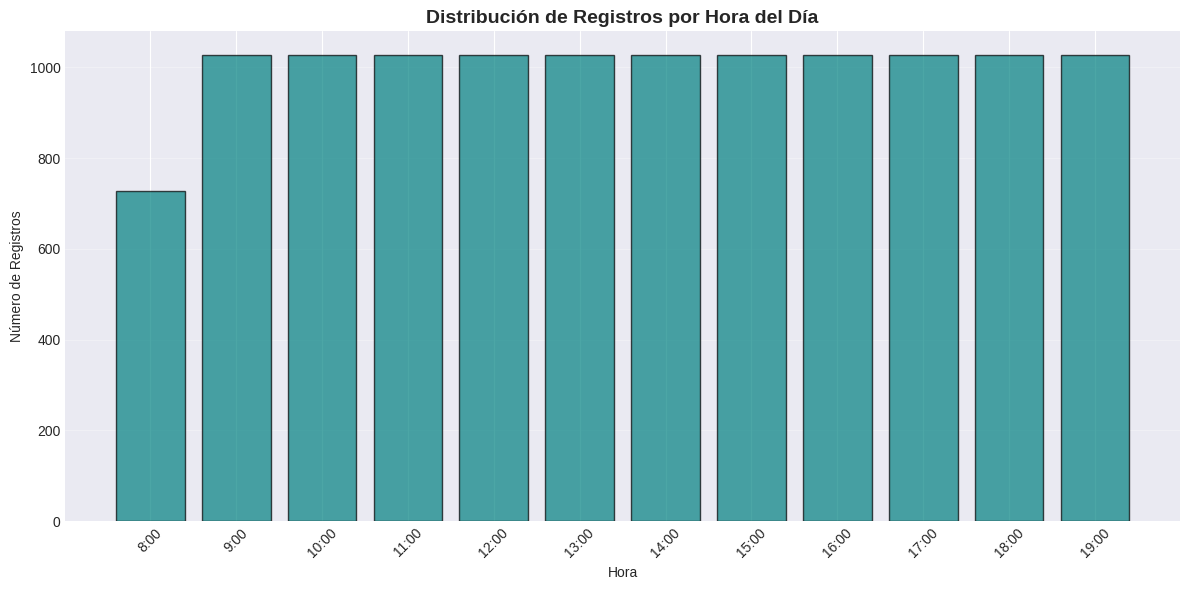

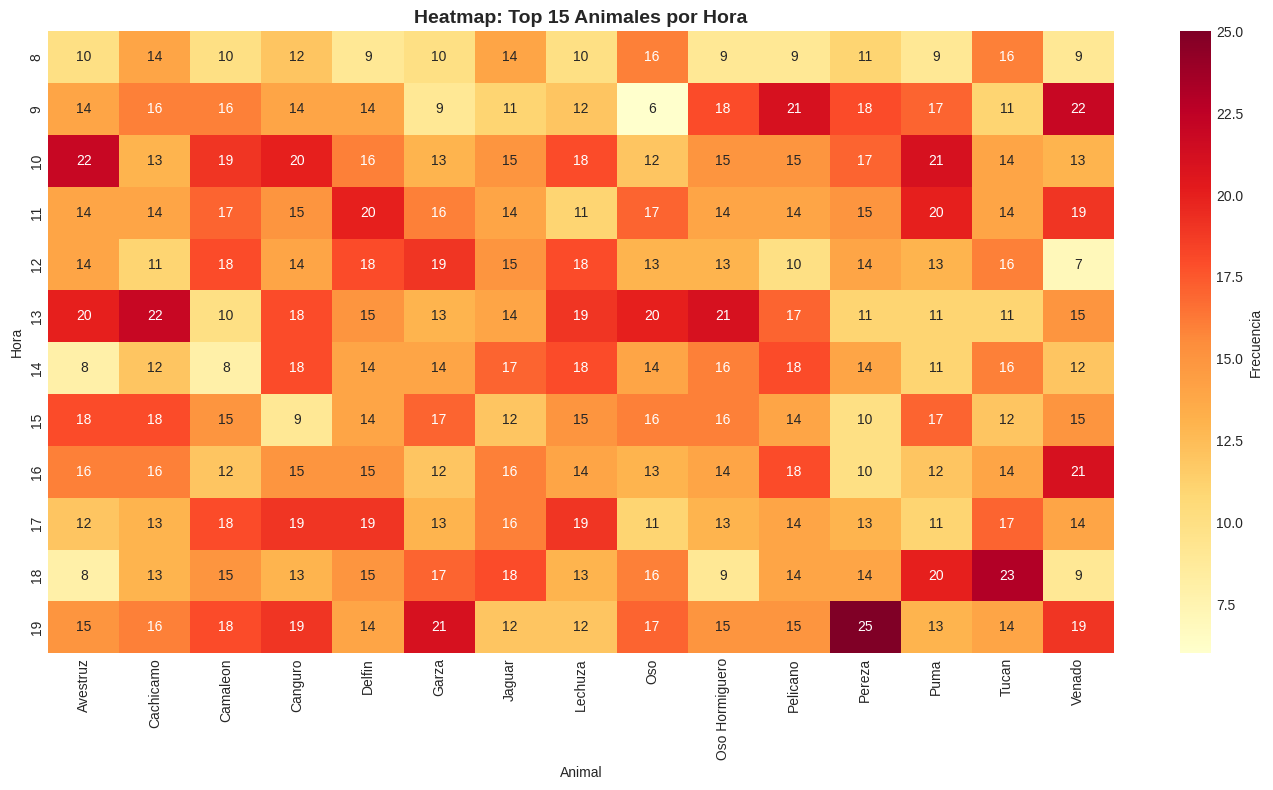

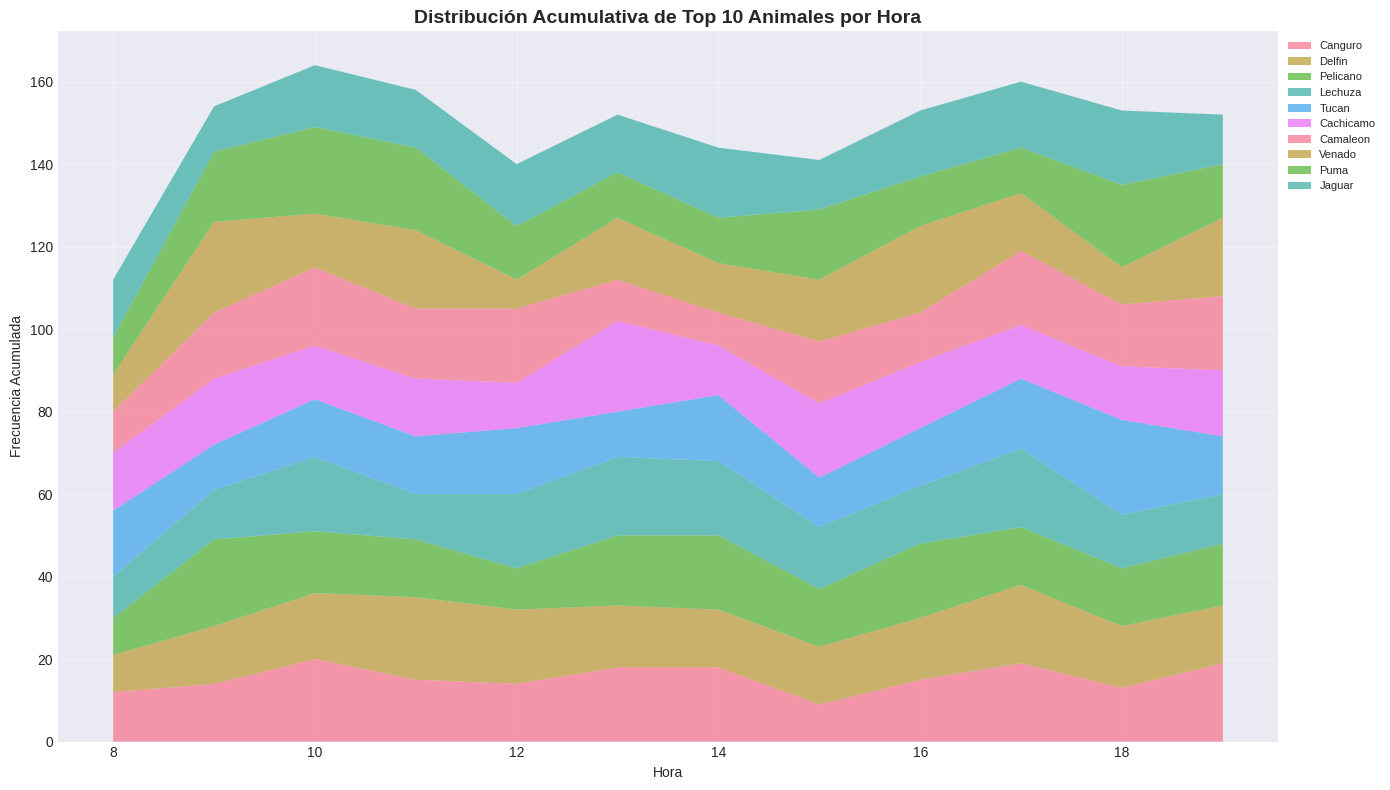

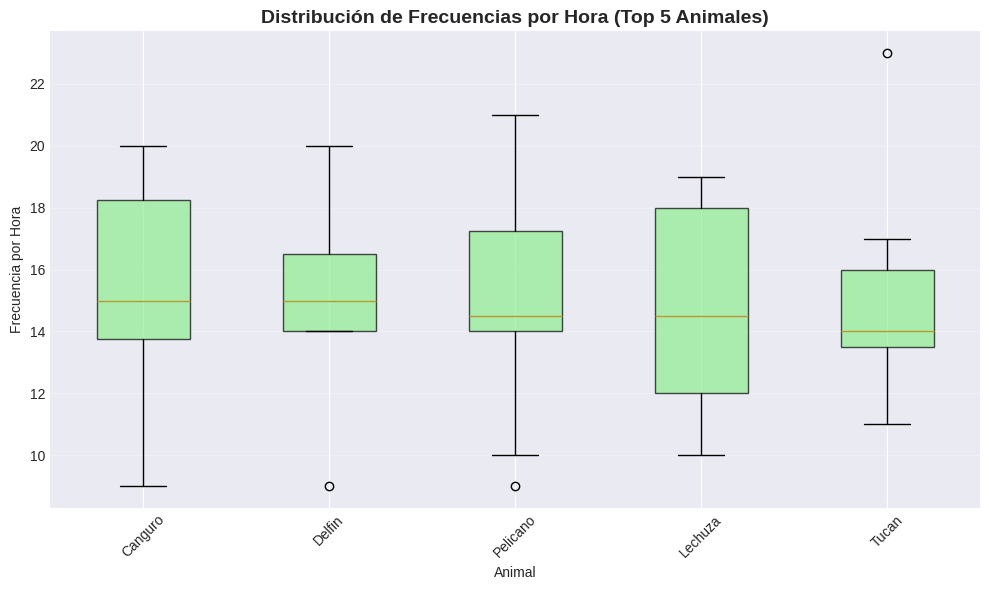

In [60]:
# Visualización por hora - GRÁFICOS INDIVIDUALES

# 1. Registros por hora
horas_labels = [f"{h}:00" for h in sorted(df['HoraNum'].unique())]
plt.figure(figsize=(12, 6))
plt.bar(horas_labels, registros_por_hora.values, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribución de Registros por Hora del Día', fontsize=14, fontweight='bold')
plt.xlabel('Hora')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Heatmap de animales por hora (top 15 animales)
top_15_animales = frecuencia_animales.head(15).index
df_top15 = df[df['Animal'].isin(top_15_animales)]
heatmap_data = pd.crosstab(df_top15['HoraNum'], df_top15['Animal'])
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Frecuencia'})
plt.title('Heatmap: Top 15 Animales por Hora', fontsize=14, fontweight='bold')
plt.xlabel('Animal')
plt.ylabel('Hora')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3. Distribución de animales por hora (stacked area)
animales_por_hora = pd.crosstab(df['HoraNum'], df['Animal'])
top_10_por_hora = animales_por_hora[top_10.index].T
plt.figure(figsize=(14, 8))
plt.stackplot(sorted(df['HoraNum'].unique()), 
             *[top_10_por_hora.loc[animal] for animal in top_10.index],
             labels=top_10.index, alpha=0.7)
plt.title('Distribución Acumulativa de Top 10 Animales por Hora', fontsize=14, fontweight='bold')
plt.xlabel('Hora')
plt.ylabel('Frecuencia Acumulada')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Boxplot de frecuencias por hora para top 5 animales
top_5_animales = frecuencia_animales.head(5).index
data_boxplot = []
labels_boxplot = []
for animal in top_5_animales:
    frecuencias_hora = []
    for hora in sorted(df['HoraNum'].unique()):
        count = len(df[(df['HoraNum'] == hora) & (df['Animal'] == animal)])
        frecuencias_hora.append(count)
    data_boxplot.append(frecuencias_hora)
    labels_boxplot.append(animal)

plt.figure(figsize=(10, 6))
plt.boxplot(data_boxplot, labels=labels_boxplot, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7))
plt.title('Distribución de Frecuencias por Hora (Top 5 Animales)', fontsize=14, fontweight='bold')
plt.xlabel('Animal')
plt.ylabel('Frecuencia por Hora')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Análisis Temporal Avanzado


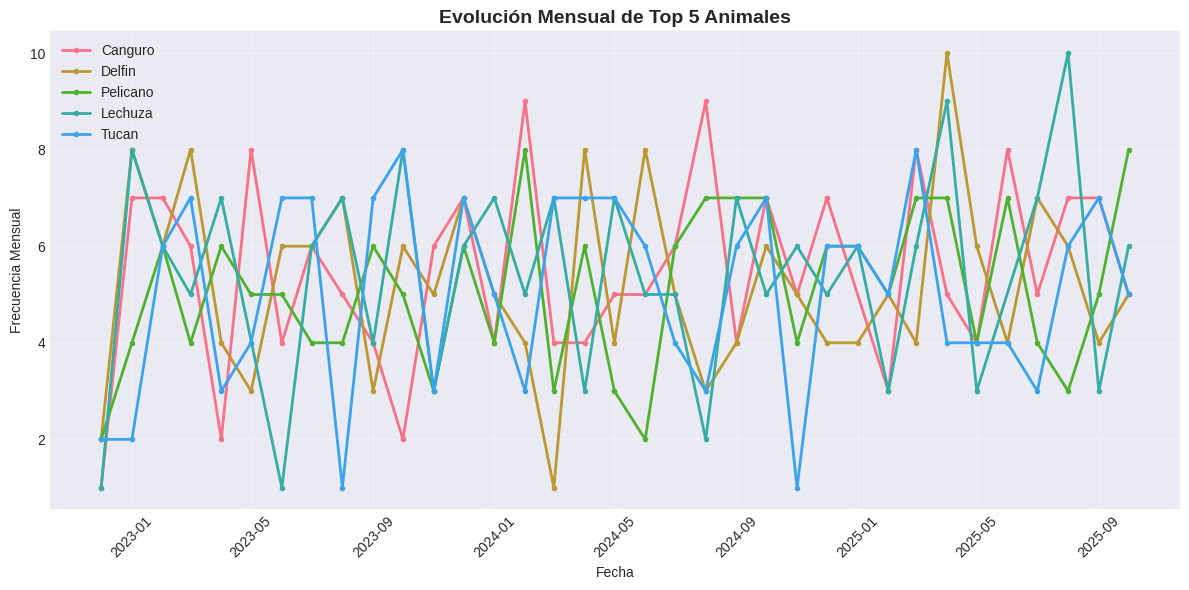

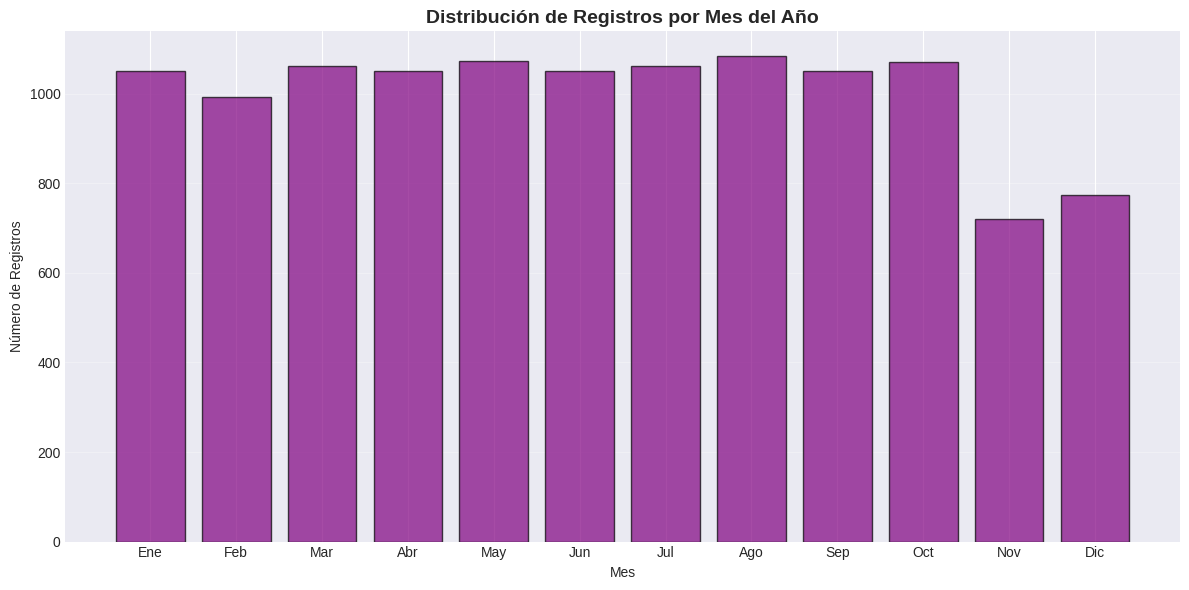

In [61]:
# Evolución temporal de animales más frecuentes - GRÁFICOS INDIVIDUALES

# 1. Evolución mensual del top 5 animales
top_5 = frecuencia_animales.head(5).index
evolucion_mensual = df.groupby([df['Fecha'].dt.to_period('M'), 'Animal']).size().reset_index(name='Count')
evolucion_mensual['Fecha'] = evolucion_mensual['Fecha'].astype(str)

plt.figure(figsize=(12, 6))
for animal in top_5:
    datos_animal = evolucion_mensual[evolucion_mensual['Animal'] == animal]
    datos_animal['Fecha'] = pd.to_datetime(datos_animal['Fecha'])
    plt.plot(datos_animal['Fecha'], datos_animal['Count'], marker='o', label=animal, linewidth=2, markersize=3)

plt.title('Evolución Mensual de Top 5 Animales', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia Mensual')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Distribución por mes del año
registros_por_mes_anual = df.groupby('Mes').size()
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(12, 6))
plt.bar(registros_por_mes_anual.index, registros_por_mes_anual.values, 
        color='purple', edgecolor='black', alpha=0.7)
plt.title('Distribución de Registros por Mes del Año', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Número de Registros')
plt.xticks(range(1, 13), meses_nombres)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()




## 8. Análisis de Patrones y Correlaciones


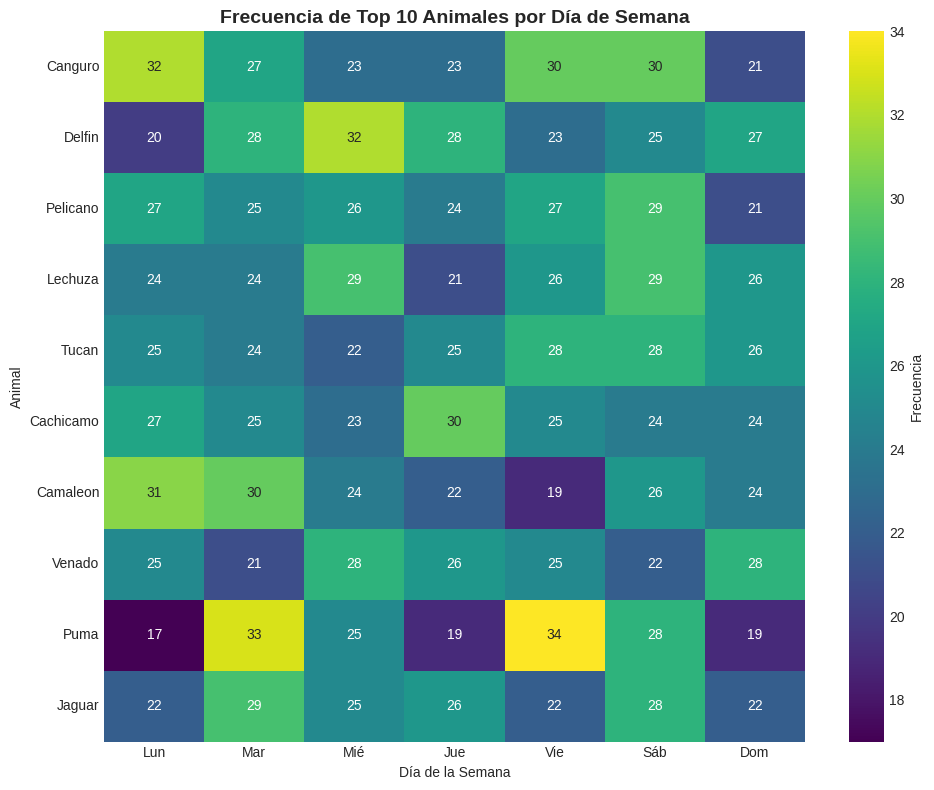

In [62]:
# Análisis de secuencias y patrones - GRÁFICOS INDIVIDUALES

# 1. Matriz de co-ocurrencia de animales (mismo día, horas consecutivas)
# Crear pares de animales que aparecen en horas consecutivas el mismo día
pares_consecutivos = []
for fecha in df['Fecha'].unique():
    df_fecha = df[df['Fecha'] == fecha].sort_values('HoraNum')
    animales_fecha = df_fecha['Animal'].dropna().values
    for i in range(len(animales_fecha) - 1):
        pares_consecutivos.append((animales_fecha[i], animales_fecha[i+1]))

pares_df = pd.DataFrame(pares_consecutivos, columns=['Animal1', 'Animal2'])
co_ocurrencia = pd.crosstab(pares_df['Animal1'], pares_df['Animal2'])



# 2. Distribución de animales por día de semana (heatmap)
animales_dia_semana = pd.crosstab(df['DiaSemanaNum'], df['Animal'])
top_10_diasemana = animales_dia_semana[top_10.index].T.fillna(0).astype(int)
dias_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

plt.figure(figsize=(10, 8))
sns.heatmap(top_10_diasemana, annot=True, fmt='d', cmap='viridis',
            cbar_kws={'label': 'Frecuencia'}, xticklabels=dias_labels)
plt.title('Frecuencia de Top 10 Animales por Día de Semana', 
          fontsize=14, fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Animal')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


